# 04 — Cash Demand Forecasting Project

**Hour 2, 115–120 min: Mini challenge, then the complete pipeline**

Two things happen in this notebook:
1. A **mini challenge** — see with your own eyes whether adding a new feature actually
   improves the forecast.
2. Wrapping the whole workflow into **one reusable pipeline** — the capstone shape from the
   slides:

```
Raw Data → Clean Data → Sort by Date → Visualize → Understand Patterns →
Create Lags → Create Time Features → Train/Test Split → Baseline → Model →
Forecast → Evaluate → Business Interpretation
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (11, 5)

## Mini Challenge: Does a New Feature Actually Help?

**The task:**
1. Create a new lag feature (`Lag_14` — the value from 14 days ago).
2. We already have day of week as a feature; add it again explicitly here so it's easy to see.
3. Retrain the forecasting model with this extra feature.
4. Compare its error against the ORIGINAL model from Notebook 03 (features: `Lag_1`, `Lag_7`,
   `DayOfWeekNum`, `MonthNum`, `IsWeekend`).
5. Decide: did the new feature actually improve the forecast?

In [2]:
df = pd.read_csv("../data/bank_cash_withdrawal_timeseries.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df["Lag_1"] = df["WithdrawalAmount"].shift(1)
df["Lag_7"] = df["WithdrawalAmount"].shift(7)
df["Lag_14"] = df["WithdrawalAmount"].shift(14)   # NEW
df["DayOfWeekNum"] = df["Date"].dt.dayofweek
df["MonthNum"] = df["Date"].dt.month

df = df.dropna().reset_index(drop=True)

TEST_DAYS = 60
split_index = len(df) - TEST_DAYS
train, test = df.iloc[:split_index], df.iloc[split_index:]

original_features = ["Lag_1", "Lag_7", "DayOfWeekNum", "MonthNum", "IsWeekend"]
new_features = ["Lag_1", "Lag_7", "Lag_14", "DayOfWeekNum", "MonthNum", "IsWeekend"]

def evaluate(feature_cols):
    model = LinearRegression().fit(train[feature_cols], train["WithdrawalAmount"])
    pred = model.predict(test[feature_cols])
    mae = mean_absolute_error(test["WithdrawalAmount"], pred)
    rmse = root_mean_squared_error(test["WithdrawalAmount"], pred)
    mape = mean_absolute_percentage_error(test["WithdrawalAmount"], pred) * 100
    return mae, rmse, mape

orig_mae, orig_rmse, orig_mape = evaluate(original_features)
new_mae, new_rmse, new_mape = evaluate(new_features)

print("ORIGINAL model (5 features):")
print(f"  MAE: {orig_mae:,.0f}   RMSE: {orig_rmse:,.0f}   MAPE: {orig_mape:.1f}%")
print()
print("WITH Lag_14 added (6 features):")
print(f"  MAE: {new_mae:,.0f}   RMSE: {new_rmse:,.0f}   MAPE: {new_mape:.1f}%")
print()
change = (orig_mae - new_mae) / orig_mae * 100
print(f"Change in MAE: {change:+.1f}%  ({'improvement' if change > 0 else 'no improvement / worse'})")

ORIGINAL model (5 features):
  MAE: 4,649,825   RMSE: 6,411,498   MAPE: 16.4%

WITH Lag_14 added (6 features):
  MAE: 4,259,589   RMSE: 5,990,005   MAPE: 15.1%

Change in MAE: +8.4%  (improvement)


**Discussion — answer these for yourself:**
- Did the model improve? By how much?
- Why might `Lag_14` help (or not help)? Think about what it represents — the value from
  exactly two weeks ago. Does our data actually have a *two-week* pattern, or mainly a
  *one-week* pattern (which `Lag_7` already captures)?
- Does adding more features always make a model better? (Hint: no — a feature only helps if it
  carries NEW information the model didn't already have. `Lag_14` may end up highly similar to
  `Lag_7` on a strongly weekly-seasonal series like ours, so it can add little — or even
  slightly confuse the model with redundant noise.)
- Try your own idea: what about adding `IsHolidayIndicator` as a feature instead? Would you
  expect that to help more or less than `Lag_14`? Try it below if you like.

## The Complete Pipeline

Now let's wrap the entire workflow into one clean, reusable function.

In [3]:
def forecast_cash_demand(csv_path, feature_cols, test_days=60):
    """
    Runs the complete time series forecasting pipeline:
    load -> clean -> sort -> feature engineering -> time-based split ->
    baseline -> model -> evaluate -> return results.
    """
    # 1. Raw data
    data = pd.read_csv(csv_path, parse_dates=["Date"])

    # 2. Clean + sort by date (never assume the file is already sorted)
    data = data.sort_values("Date").reset_index(drop=True)

    # 3. Create lag and calendar features
    data["Lag_1"] = data["WithdrawalAmount"].shift(1)
    data["Lag_7"] = data["WithdrawalAmount"].shift(7)
    data["DayOfWeekNum"] = data["Date"].dt.dayofweek
    data["MonthNum"] = data["Date"].dt.month
    data = data.dropna().reset_index(drop=True)

    # 4. Time-based train/test split
    split_index = len(data) - test_days
    train_data, test_data = data.iloc[:split_index], data.iloc[split_index:]

    # 5. Baseline: naive forecast
    naive_pred = test_data["Lag_1"]
    naive_mae = mean_absolute_error(test_data["WithdrawalAmount"], naive_pred)

    # 6. Model
    model = LinearRegression().fit(train_data[feature_cols], train_data["WithdrawalAmount"])
    forecast = model.predict(test_data[feature_cols])

    # 7. Evaluate
    model_mae = mean_absolute_error(test_data["WithdrawalAmount"], forecast)
    model_rmse = root_mean_squared_error(test_data["WithdrawalAmount"], forecast)
    model_mape = mean_absolute_percentage_error(test_data["WithdrawalAmount"], forecast) * 100

    results = {
        "test_dates": test_data["Date"],
        "actual": test_data["WithdrawalAmount"],
        "forecast": forecast,
        "naive_mae": naive_mae,
        "model_mae": model_mae,
        "model_rmse": model_rmse,
        "model_mape": model_mape,
        "beat_baseline": model_mae < naive_mae,
    }
    return results


results = forecast_cash_demand(
    "../data/bank_cash_withdrawal_timeseries.csv",
    feature_cols=["Lag_1", "Lag_7", "DayOfWeekNum", "MonthNum", "IsWeekend"],
)

print(f"Naive baseline MAE: {results['naive_mae']:,.0f}")
print(f"Model MAE:          {results['model_mae']:,.0f}")
print(f"Model RMSE:         {results['model_rmse']:,.0f}")
print(f"Model MAPE:         {results['model_mape']:.1f}%")
print(f"Did the model beat the baseline? {results['beat_baseline']}")

Naive baseline MAE: 8,223,256
Model MAE:          4,651,968
Model RMSE:         6,412,993
Model MAPE:         16.4%
Did the model beat the baseline? True


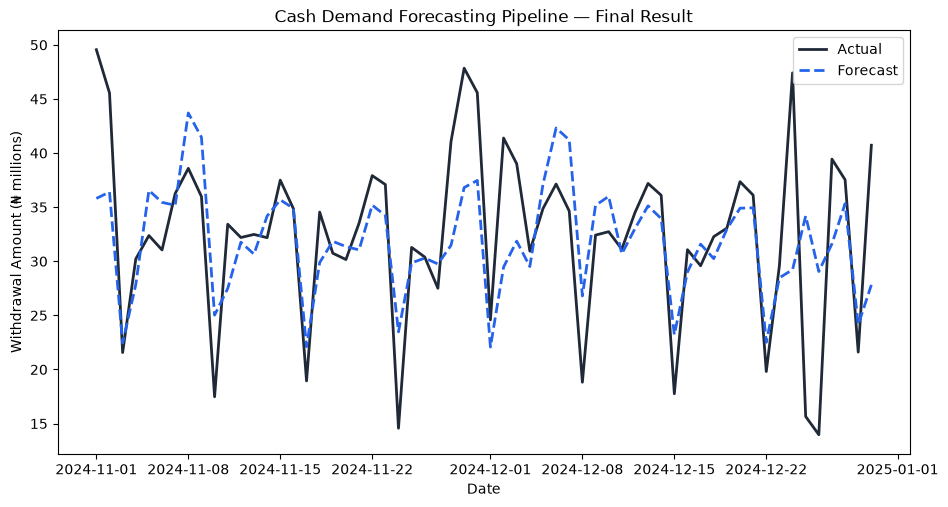

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(results["test_dates"], results["actual"] / 1e6, color="#1F2937", linewidth=2, label="Actual")
ax.plot(results["test_dates"], results["forecast"] / 1e6, color="#2563EB", linewidth=2, linestyle="--", label="Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Withdrawal Amount (₦ millions)")
ax.set_title("Cash Demand Forecasting Pipeline — Final Result")
ax.legend()
plt.show()

## Business Interpretation

Answer these questions for the bank's cash operations team:

1. **Is there a trend?** Yes — withdrawals have grown steadily over the two years of history.
2. **Is there weekly seasonality?** Yes, strongly — Fridays/Saturdays are busiest, Sundays are
   quietest, driven by which days most branches and customers are active.
3. **Which features were useful?** `Lag_1` and `Lag_7` (and day-of-week) captured most of the
   useful signal; `Lag_14` added little on top of `Lag_7` for this particular series.
4. **How accurate was the forecast?** Roughly ₦4.7M average error (MAE), about 16% MAPE — a
   meaningfully more accurate forecast than simply assuming "tomorrow = today."
5. **Did the model beat the baseline?** Yes, by a wide margin (~43% lower MAE).
6. **How could the bank use this forecast?** Adjust cash-loading schedules ahead of high-demand
   days (Fridays, month-end, the day before public holidays), reducing the risk of ATM cash-outs
   while avoiding unnecessarily high idle cash reserves on quiet days like Sundays.

### Recap — you have now built a complete, working forecasting system:
Raw data → cleaned and sorted → visualized → understood (trend + weekly seasonality) →
turned into lag/calendar features → split correctly by time → compared against a naive
baseline → modeled → evaluated → interpreted for the business.

This is the exact shape of a real-world forecasting project, just with fewer features and a
simpler model than you'd eventually reach for in production. The workflow itself does not
change much as problems get more advanced — only the modeling step usually gets more
sophisticated.